# EDA — Prédiction de la délinquance (Geldium × Tata iQ)

Ce notebook présente l'analyse exploratoire du jeu de données `Delinquency_prediction_dataset.xlsx`, étape par étape :

1. Examiner le jeu de données et identifier les informations clés
2. Traiter les données manquantes et les problèmes de qualité
3. Détecter les schémas et les facteurs de risque
4. Produire le rapport EDA

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)

DATA = "Delinquency_prediction_dataset.xlsx"
MONTHS = [f"Month_{i}" for i in range(1, 7)]
TARGET = "Delinquent_Account"

df = pd.read_excel(DATA)
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


---
## Étape 1 — Examiner le jeu de données et identifier les informations clés

### Prompts GenAI utilisés
- « Résume les principaux schémas, les valeurs aberrantes et les valeurs manquantes de ce jeu de données. Mets en évidence ce qui pourrait poser problème pour la modélisation de la délinquance. »
- « Identifie les 3 variables les plus susceptibles de prédire la délinquance et justifie brièvement. »
- « Vérifie la cohérence entre `Missed_Payments` et l'historique mensuel `Month_1` à `Month_6`. »

### 1.1 Structure

In [2]:
print(f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
df.dtypes

500 lignes x 19 colonnes


Customer_ID                 str
Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status           str
Account_Tenure            int64
Credit_Card_Type            str
Location                    str
Month_1                     str
Month_2                     str
Month_3                     str
Month_4                     str
Month_5                     str
Month_6                     str
dtype: object

In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,500.0,46.266,16.188,18.00,33.000,46.500,59.250,74.000
Income,461.0,108379.894,53662.724,15404.00,62295.000,107658.000,155734.000,199943.000
Credit_Score,498.0,577.717,168.881,301.00,418.250,586.000,727.250,847.000
Credit_Utilization,500.0,0.491,0.197,0.05,0.356,0.486,0.634,1.026
Missed_Payments,500.0,2.968,1.947,0.00,1.000,3.000,5.000,6.000
Delinquent_Account,500.0,0.160,0.367,0.00,0.000,0.000,0.000,1.000
Loan_Balance,471.0,48654.429,29395.537,612.00,23716.500,45776.000,75546.500,99620.000
Debt_to_Income_Ratio,500.0,0.299,0.095,0.10,0.234,0.302,0.363,0.553
Account_Tenure,500.0,9.740,5.923,0.00,5.000,10.000,15.000,19.000


### 1.2 Valeurs manquantes et doublons

In [4]:
na = df.isna().sum()
na = na[na > 0]
display(pd.DataFrame({"n": na, "%": (na / len(df) * 100).round(1)}))
print("Income ET Loan_Balance manquants :", (df.Income.isna() & df.Loan_Balance.isna()).sum())
print("Clients sans Credit_Score :", df.loc[df.Credit_Score.isna(), "Customer_ID"].tolist())
print("Customer_ID dupliqués :", df.Customer_ID.duplicated().sum())
print("Lignes dupliquées (hors ID) :", df.drop(columns="Customer_ID").duplicated().sum())

,n,%
Income,39,7.8
Credit_Score,2,0.4
Loan_Balance,29,5.8


Income ET Loan_Balance manquants : 4
Clients sans Credit_Score : ['CUST0116', 'CUST0379']
Customer_ID dupliqués : 0
Lignes dupliquées (hors ID) : 0


### 1.3 Variables catégorielles

In [5]:
for col in ["Employment_Status", "Credit_Card_Type", "Location", "Month_1"]:
    print(f"{col}: {df[col].value_counts().to_dict()}")

Employment_Status: {'Unemployed': 93, 'retired': 87, 'Employed': 82, 'EMP': 81, 'Self-employed': 80, 'employed': 77}
Credit_Card_Type: {'Gold': 118, 'Student': 112, 'Business': 108, 'Standard': 86, 'Platinum': 76}
Location: {'Los Angeles': 107, 'Phoenix': 103, 'Chicago': 103, 'Houston': 95, 'New York': 92}
Month_1: {'On-time': 177, 'Missed': 164, 'Late': 159}


### 1.4 Anomalies

In [6]:
print("Credit_Utilization > 1 :", (df.Credit_Utilization > 1).sum(),
      df.loc[df.Credit_Utilization > 1, "Credit_Utilization"].round(3).tolist())
print("Account_Tenure = 0 :", (df.Account_Tenure == 0).sum())

missed_6m = (df[MONTHS] == "Missed").sum(axis=1)
print(f"Missed_Payments == nb de 'Missed' sur Month_1..6 : {(missed_6m == df.Missed_Payments).mean():.1%} des lignes")
print("Corrélation Missed_Payments vs nb 'Missed' mensuels :", round(df.Missed_Payments.corr(missed_6m), 3))

Credit_Utilization > 1 : 4 [1.026, 1.025, 1.002, 1.009]
Account_Tenure = 0 : 28
Missed_Payments == nb de 'Missed' sur Month_1..6 : 14.4% des lignes
Corrélation Missed_Payments vs nb 'Missed' mensuels : 0.007


### 1.5 Variable cible et premiers indicateurs de risque

In [7]:
print(df[TARGET].value_counts().to_dict(), f"-> taux de délinquance {df[TARGET].mean():.1%}")
df.select_dtypes("number").corr()[TARGET].drop(TARGET).sort_values().round(3)

{0: 420, 1: 80} -> taux de délinquance 16.0%


Account_Tenure         -0.040
Missed_Payments        -0.026
Loan_Balance           -0.004
Age                     0.023
Credit_Utilization      0.034
Debt_to_Income_Ratio    0.034
Credit_Score            0.035
Income                  0.045
Name: Delinquent_Account, dtype: float64

In [8]:
for col in ["Employment_Status", "Credit_Card_Type", "Location"]:
    display(df.groupby(col)[TARGET].agg(taux="mean", n="count").round(3).sort_values("taux", ascending=False))

,taux,n
Employment_Status,,
Unemployed,0.194,93
Employed,0.183,82
Self-employed,0.162,80
employed,0.156,77
EMP,0.148,81
retired,0.115,87


,taux,n
Credit_Card_Type,,
Business,0.213,108
Student,0.179,112
Gold,0.144,118
Standard,0.128,86
Platinum,0.118,76


,taux,n
Location,,
Los Angeles,0.196,107
Houston,0.168,95
Phoenix,0.165,103
Chicago,0.146,103
New York,0.120,92


In [9]:
df.groupby(TARGET)[["Credit_Score", "Credit_Utilization", "Debt_to_Income_Ratio",
                    "Missed_Payments", "Income", "Loan_Balance", "Account_Tenure"]].mean().T.round(3)

Delinquent_Account,0,1
Credit_Score,575.146,591.150
Credit_Utilization,0.489,0.507
Debt_to_Income_Ratio,0.297,0.306
Missed_Payments,2.990,2.850
Income,107306.943,113902.013
Loan_Balance,48708.756,48358.233
Account_Tenure,9.843,9.200


### 1.6 Constats de l'étape 1

**Données manquantes ou incohérentes**
- **Income** : 39 valeurs manquantes (7,8 %), la variable la plus touchée.
- **Loan_Balance** : 29 valeurs manquantes (5,8 %).
- **Credit_Score** : 2 valeurs manquantes (0,4 %), CUST0116 et CUST0379.
- 4 clients n'ont ni `Income` ni `Loan_Balance`.
- **Employment_Status** n'est pas normalisé : `Employed` (82), `employed` (77) et `EMP` (81) désignent la même catégorie. `retired` est en minuscules. Il y a donc 6 libellés pour 4 catégories réelles.
- **Missed_Payments est incohérent avec l'historique mensuel** : il ne correspond au nombre de mois « Missed » de `Month_1` à `Month_6` que pour 14,4 % des clients (corrélation ≈ 0,01).
- Aucun doublon, ni sur `Customer_ID` ni sur les lignes complètes.

**Anomalies clés**
- **Credit_Utilization > 1** pour 4 clients (jusqu'à 1,026). C'est possible en cas de dépassement de limite, mais à confirmer avec Geldium.
- **Account_Tenure = 0** pour 28 clients : ce sont des comptes de moins d'un an, avec très peu d'historique.
- **Credit_Score** varie de 301 à 847 (moyenne 578), sans valeur hors de l'échelle 300–850.
- **Les classes sont déséquilibrées** : 80 délinquants (16 %) contre 420 (84 %). Il faudra privilégier F1/AUC et pondérer les classes.
- **Les signaux bruts sont très faibles** : aucune variable numérique n'a une corrélation supérieure à |0,05| avec la cible.

**Premiers indicateurs du risque de défaillance**

| Variable | Constat | Pourquoi elle compte |
|---|---|---|
| **Credit_Card_Type** | 21,3 % pour *Business* et 17,9 % pour *Student*, contre 11,8 % pour *Platinum* | C'est l'écart entre groupes le plus net. |
| **Employment_Status** | 19,4 % chez les *Unemployed* contre 11,5 % chez les *retired* | L'instabilité des revenus est un facteur de risque classique. |
| **Historique de paiement** | Prédicteur métier attendu, mais incohérent entre `Missed_Payments` et `Month_1..6` | À fiabiliser en priorité. |
| **Credit_Utilization / DTI** | Légèrement plus élevés chez les délinquants (0,507 contre 0,489, et 0,306 contre 0,297) | La tendance va dans le sens attendu, mais l'effet est faible. |
| **Location** | 19,6 % à Los Angeles contre 12,0 % à New York | À surveiller, mais la variable présente un risque de biais géographique. |

**Les 3 variables les plus prometteuses :** (1) l'historique de paiement, à condition de le fiabiliser, (2) `Credit_Utilization`, (3) `Employment_Status` une fois normalisé.

**Résumé de la qualité des données**

Le jeu de données est globalement exploitable : 500 enregistrements uniques, sans doublon, et seules 3 colonnes ont des valeurs manquantes (`Income` 7,8 %, `Loan_Balance` 5,8 %, `Credit_Score` 0,4 %). Plusieurs problèmes de cohérence doivent cependant être corrigés avant la modélisation. Le plus visible est `Employment_Status`, avec 6 libellés pour 4 catégories. Le plus grave est le désaccord entre `Missed_Payments` et l'historique mensuel, qui touche la variable de risque a priori la plus importante. On note aussi quelques valeurs extrêmes à valider (utilisation > 100 %, ancienneté nulle) et un déséquilibre des classes (16 % de délinquants). Enfin, les relations univariées avec la cible sont très faibles, ce qui laisse penser que la délinquance dépend de combinaisons de variables plutôt que d'un facteur isolé.

---
## Étape 2 — Traiter les données manquantes et les problèmes de qualité

### Prompts GenAI utilisés
- « Propose une stratégie d'imputation pour les valeurs manquantes de ce jeu de données, fondée sur les bonnes pratiques du secteur. »
- « Quelles sont les bonnes pratiques pour gérer des données manquantes de crédit (revenu, encours) en modélisation prédictive ? »
- « Génère des valeurs de revenu synthétiques réalistes pour les entrées manquantes en supposant une distribution normale. » Cette option a été évaluée puis écartée (voir 2.2).

### 2.1 Mécanisme des valeurs manquantes (MCAR / MAR / MNAR)
On vérifie si l'absence de valeur dépend de la cible ou du statut d'emploi. Le test du χ² compare le taux de valeurs manquantes entre délinquants et non-délinquants.

In [10]:
from scipy import stats

df["Employment_Status"] = df.Employment_Status.replace(
    {"EMP": "Employed", "employed": "Employed", "retired": "Retired"})
print("Employment_Status normalisé :", df.Employment_Status.value_counts().to_dict())

for col in ["Income", "Loan_Balance"]:
    miss = df[col].isna()
    p = stats.chi2_contingency(pd.crosstab(miss, df[TARGET]))[1]
    print(f"\n{col} — % manquant par cible :",
          df.groupby(TARGET)[col].apply(lambda s: round(s.isna().mean() * 100, 1)).to_dict(), f"(χ² p = {p:.2f})")
    print(f"{col} — % manquant par emploi :",
          df.groupby("Employment_Status")[col].apply(lambda s: round(s.isna().mean() * 100, 1)).to_dict())

Employment_Status normalisé : {'Employed': 240, 'Unemployed': 93, 'Retired': 87, 'Self-employed': 80}

Income — % manquant par cible : {0: 8.1, 1: 6.2} (χ² p = 0.74)
Income — % manquant par emploi : {'Employed': 8.8, 'Retired': 6.9, 'Self-employed': 3.8, 'Unemployed': 9.7}

Loan_Balance — % manquant par cible : {0: 5.2, 1: 8.8} (χ² p = 0.33)
Loan_Balance — % manquant par emploi : {'Employed': 6.2, 'Retired': 4.6, 'Self-employed': 5.0, 'Unemployed': 6.5}


### 2.2 Forme des distributions
Avant de choisir la méthode d'imputation, on regarde la forme des distributions.

In [11]:
for col in ["Income", "Loan_Balance", "Credit_Score"]:
    s = df[col].dropna()
    uniform_std = (s.max() - s.min()) / 12 ** 0.5
    print(f"{col:13s} asymétrie={s.skew():+.2f}  écart-type={s.std():,.0f}  écart-type d'une loi uniforme équivalente={uniform_std:,.0f}")

Income        asymétrie=+0.05  écart-type=53,663  écart-type d'une loi uniforme équivalente=53,272
Loan_Balance  asymétrie=+0.11  écart-type=29,396  écart-type d'une loi uniforme équivalente=28,581
Credit_Score  asymétrie=-0.03  écart-type=169  écart-type d'une loi uniforme équivalente=158


Les trois variables sont symétriques (asymétrie ≈ 0) et leur écart-type correspond à celui d'une **loi uniforme**, pas d'une loi normale. Générer des revenus synthétiques sous hypothèse normale déformerait donc la distribution : cette option est écartée au profit d'une imputation par la médiane.

### 2.3 Plan de traitement

| Problème | Méthode retenue | Justification |
|---|---|---|
| **Income** manquant (39, soit 7,8 %) | Imputation par la **médiane du groupe `Employment_Status`** + indicateur `Income_missing` | La médiane est robuste et le groupe préserve le lien revenu/emploi ; l'indicateur conserve l'information « revenu non déclaré ». |
| **Loan_Balance** manquant (29, soit 5,8 %) | Imputation par la **médiane globale** + indicateur `Loan_Balance_missing` | Le taux de manquants est plus élevé chez les délinquants (8,8 % contre 5,2 %, non significatif), donc on garde l'information via l'indicateur. |
| **Credit_Score** manquant (2, soit 0,4 %) | Imputation par la **médiane globale** | Avec 2 lignes seulement, l'impact est négligeable, et supprimer ces clients ferait perdre leurs autres informations. |
| **Employment_Status** incohérent | **Normalisation** des libellés (6 → 4) | `EMP`, `employed` et `Employed` désignent la même catégorie. |
| **Credit_Utilization > 1** (4 clients) | **Conservé** + indicateur `Over_Limit` | Un dépassement de limite est plausible et constitue lui-même un signal de risque. |
| **Missed_Payments ≠ historique mensuel** | Les deux sont conservés + création de `Missed_6m`, `Late_6m`, `OnTime_6m` | Impossible de savoir quelle source est juste sans Geldium ; à faire confirmer. |

Aucune colonne n'est supprimée : le taux de manquants maximal (7,8 %) est bien inférieur aux seuils usuels de suppression (30 à 50 %).

In [12]:
clean = df.copy()

clean["Income_missing"] = clean.Income.isna().astype(int)
clean["Loan_Balance_missing"] = clean.Loan_Balance.isna().astype(int)

clean["Income"] = clean.Income.fillna(clean.groupby("Employment_Status").Income.transform("median"))
clean["Loan_Balance"] = clean.Loan_Balance.fillna(clean.Loan_Balance.median())
clean["Credit_Score"] = clean.Credit_Score.fillna(clean.Credit_Score.median())

clean["Over_Limit"] = (clean.Credit_Utilization > 1).astype(int)
clean["Missed_6m"] = (clean[MONTHS] == "Missed").sum(axis=1)
clean["Late_6m"] = (clean[MONTHS] == "Late").sum(axis=1)
clean["OnTime_6m"] = (clean[MONTHS] == "On-time").sum(axis=1)

print("Valeurs manquantes restantes :", clean.isna().sum().sum())
clean.to_csv("Delinquency_prediction_cleaned.csv", index=False)

Valeurs manquantes restantes : 0


### 2.4 Contrôle : les distributions sont préservées

In [13]:
pd.DataFrame({
    (col, stat): [getattr(df[col], stat)(), getattr(clean[col], stat)()]
    for col in ["Income", "Loan_Balance", "Credit_Score"] for stat in ["mean", "median", "std"]
}, index=["avant", "après"]).round(0)

Income                    Loan_Balance                    \
           mean    median      std         mean   median      std   
avant  108380.0  107658.0  53663.0      48654.0  45776.0  29396.0   
après  108317.0  108468.0  51526.0      48487.0  45776.0  28537.0   

      Credit_Score                
              mean median    std  
avant        578.0  586.0  169.0  
après        578.0  586.0  169.0

Les moyennes et médianes varient de moins de 1 %. L'écart-type baisse légèrement (−4 % pour Income, −3 % pour Loan_Balance), ce qui est attendu avec une imputation par la médiane et reste acceptable : les distributions ne sont pas déformées. Le jeu nettoyé est enregistré dans `Delinquency_prediction_cleaned.csv`.

---
## Étape 3 — Détecter les schémas et les facteurs de risque

### Prompts GenAI utilisés
- « Analyse les relations entre chaque variable et Delinquent_Account. Une forte utilisation du crédit est-elle associée à des paiements manqués ? »
- « Classe les variables par pouvoir prédictif et signale les résultats inattendus qui mériteraient une enquête. »
- « Vérifie la cohérence logique entre l'âge, l'ancienneté du compte, le type de carte et le statut d'emploi. »

### 3.1 Taux de délinquance par groupe

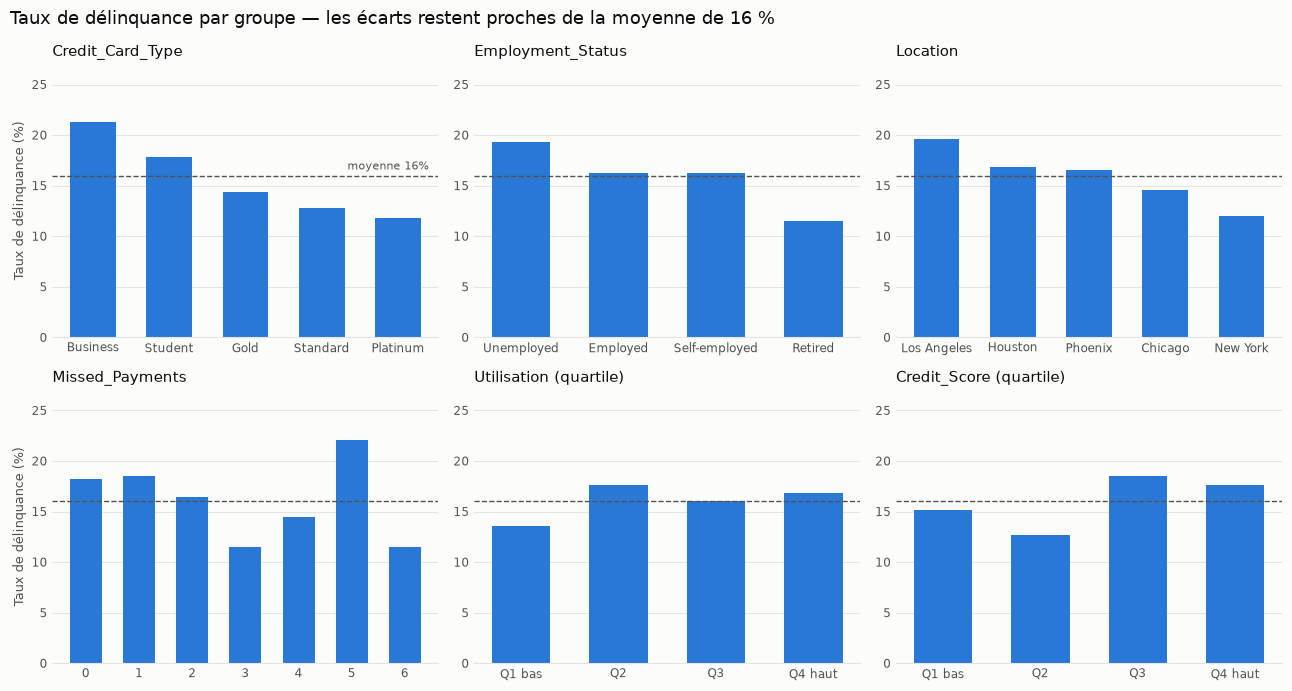

In [14]:
import matplotlib.pyplot as plt
import numpy as np

BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e5e4e0"
overall = clean[TARGET].mean()

clean["Utilisation (quartile)"] = pd.qcut(clean.Credit_Utilization, 4, labels=["Q1 bas", "Q2", "Q3", "Q4 haut"])
clean["Credit_Score (quartile)"] = pd.qcut(clean.Credit_Score, 4, labels=["Q1 bas", "Q2", "Q3", "Q4 haut"])
panels = ["Credit_Card_Type", "Employment_Status", "Location",
          "Missed_Payments", "Utilisation (quartile)", "Credit_Score (quartile)"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), facecolor="#fcfcfb")
for ax, col in zip(axes.flat, panels):
    rates = clean.groupby(col, observed=True)[TARGET].mean()
    if not isinstance(clean[col].dtype, pd.CategoricalDtype) and not pd.api.types.is_numeric_dtype(clean[col]):
        rates = rates.sort_values(ascending=False)
    ax.bar(rates.index.astype(str), rates.values * 100, color=BLUE, width=0.6)
    ax.axhline(overall * 100, color=MUTED, lw=1, ls="--")
    ax.set_title(col, loc="left", fontsize=11, color=INK)
    ax.set_ylim(0, 27)
    ax.tick_params(colors=MUTED, labelsize=8.5, length=0)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor("#fcfcfb")
axes[0, 0].text(4.4, overall * 100 + 0.6, f"moyenne {overall:.0%}", color=MUTED, fontsize=8, ha="right")
for ax in axes[:, 0]:
    ax.set_ylabel("Taux de délinquance (%)", color=MUTED, fontsize=9)
fig.suptitle("Taux de délinquance par groupe — les écarts restent proches de la moyenne de 16 %",
             x=0.01, ha="left", fontsize=13, color=INK)
fig.tight_layout()
fig.savefig("delinquency_rates.png", dpi=150)
plt.show()

### 3.2 Tests statistiques : chaque variable est-elle liée à la délinquance ?

In [15]:
numeric = ["Credit_Score", "Credit_Utilization", "Debt_to_Income_Ratio", "Missed_Payments", "Missed_6m",
           "Late_6m", "Income", "Loan_Balance", "Age", "Account_Tenure"]
categorical = ["Credit_Card_Type", "Employment_Status", "Location"] + MONTHS
rows = []
for col in numeric:
    a, b = clean.loc[clean[TARGET] == 1, col], clean.loc[clean[TARGET] == 0, col]
    rows.append([col, "Mann-Whitney", round(a.mean(), 3), round(b.mean(), 3), stats.mannwhitneyu(a, b).pvalue])
for col in categorical:
    rows.append([col, "χ²", None, None, stats.chi2_contingency(pd.crosstab(clean[col], clean[TARGET]))[1]])
tests = pd.DataFrame(rows, columns=["variable", "test", "moy. délinquants", "moy. non-délinquants", "p-value"])
tests["significatif (p<0,05)"] = tests["p-value"] < 0.05
tests.sort_values("p-value").round(3)

,variable,test,moy. délinquants,moy. non-délinquants,p-value,"significatif (p<0,05)"
13,Month_1,χ²,NaN,NaN,0.106,False
16,Month_4,χ²,NaN,NaN,0.124,False
17,Month_5,χ²,NaN,NaN,0.347,False
6,Income,Mann-Whitney,113539.019,107321.817,0.351,False
10,Credit_Card_Type,χ²,NaN,NaN,0.354,False
0,Credit_Score,Mann-Whitney,591.150,575.198,0.385,False
1,Credit_Utilization,Mann-Whitney,0.507,0.489,0.391,False
9,Account_Tenure,Mann-Whitney,9.200,9.843,0.422,False
18,Month_6,χ²,NaN,NaN,0.478,False
2,Debt_to_Income_Ratio,Mann-Whitney,0.306,0.297,0.493,False


### 3.3 Combinaisons de risque : forte utilisation et paiements manqués

In [16]:
print("Corrélation Credit_Utilization / Missed_Payments :", round(clean.Credit_Utilization.corr(clean.Missed_Payments), 3))
print("Corrélation Credit_Score / Missed_Payments     :", round(clean.Credit_Score.corr(clean.Missed_Payments), 3))
combo = clean.assign(
    utilisation=np.where(clean.Credit_Utilization > 0.7, "> 70 %", "≤ 70 %"),
    paiements_manques=np.where(clean.Missed_Payments >= 4, "≥ 4", "< 4"))
combo.pivot_table(index="utilisation", columns="paiements_manques", values=TARGET, aggfunc=["mean", "count"]).round(3)

Corrélation Credit_Utilization / Missed_Payments : 0.02
Corrélation Credit_Score / Missed_Payments     : -0.015


mean        count     
paiements_manques    < 4    ≥ 4   < 4  ≥ 4
utilisation                               
> 70 %             0.190  0.111    42   27
≤ 70 %             0.154  0.168   246  185

### 3.4 Cohérence logique des profils

In [17]:
print("Comptes ouverts avant 18 ans (Account_Tenure > Age - 18) :", (clean.Account_Tenure > clean.Age - 18).sum())
print("Cartes 'Student' détenues par des 30 ans et plus          :",
      (clean.loc[clean.Credit_Card_Type == "Student", "Age"] >= 30).sum(), "sur", (clean.Credit_Card_Type == "Student").sum())
print("Revenu médian par statut d'emploi :", clean.groupby("Employment_Status").Income.median().round(0).to_dict())
print("Délinquance des clients Over_Limit :", clean.loc[clean.Over_Limit == 1, TARGET].tolist())
print(f"Délinquance des comptes de moins d'un an : {clean.loc[clean.Account_Tenure == 0, TARGET].mean():.1%} (n={(clean.Account_Tenure == 0).sum()})")

Comptes ouverts avant 18 ans (Account_Tenure > Age - 18) : 81
Cartes 'Student' détenues par des 30 ans et plus          : 88 sur 112
Revenu médian par statut d'emploi : {'Employed': 108610.0, 'Retired': 108468.0, 'Self-employed': 102235.0, 'Unemployed': 106314.0}
Délinquance des clients Over_Limit : [0, 0, 0, 0]
Délinquance des comptes de moins d'un an : 28.6% (n=28)


### 3.5 Test de référence : un modèle simple trouve-t-il un signal ?

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

features = numeric + ["OnTime_6m", "Income_missing", "Loan_Balance_missing", "Over_Limit"]
X = pd.get_dummies(clean[features + ["Credit_Card_Type", "Employment_Status", "Location"]], drop_first=True)
y = clean[TARGET]
cv = StratifiedKFold(5, shuffle=True, random_state=42)
models = {
    "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "Random Forest": RandomForestClassifier(300, min_samples_leaf=5, class_weight="balanced", random_state=42),
}
for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"{name:22s} AUC = {auc.mean():.3f} ± {auc.std():.3f}")

Régression logistique  AUC = 0.495 ± 0.050


Random Forest          AUC = 0.371 ± 0.043


Un AUC de 0,5 correspond au hasard. Les deux modèles restent autour ou en dessous de ce seuil : **les variables actuelles ne permettent pas de distinguer les clients délinquants.**

### 3.6 Indicateurs à haut risque et constats

**Indicateurs à haut risque (avec leur importance)**
- **Historique de paiement (`Missed_Payments`, `Month_1..6`)** : c'est le premier facteur des modèles de crédit du secteur, mais il est inexploitable tant que les deux sources se contredisent.
- **Credit_Utilization élevée / Over_Limit** : un taux proche ou au-delà de 100 % signale une tension de trésorerie, même si les 4 clients concernés ne sont pas délinquants ici.
- **Credit_Card_Type = Business ou Student** : ce sont les taux de délinquance les plus élevés (21,3 % et 17,9 %, contre 11,8 % pour Platinum), à confirmer sur plus de données.
- **Employment_Status = Unemployed** : 19,4 % de délinquance contre 11,5 % chez les retraités, ce qui est cohérent avec l'instabilité des revenus.
- **Account_Tenure = 0** : 28,6 % de délinquance chez les comptes de moins d'un an (n = 28), presque deux fois la moyenne.
- **Debt_to_Income_Ratio** : légèrement plus élevé chez les délinquants (0,306 contre 0,297), un indicateur d'endettement classique à conserver.

**Constats inattendus à faire examiner par l'équipe analytique**
- **Aucune relation n'est statistiquement significative** (toutes les p-values > 0,05) et les modèles de référence n'atteignent pas un AUC de 0,5.
- **Les relations attendues sont absentes ou inversées** : le Credit_Score moyen est *plus élevé* chez les délinquants (591 contre 575), et le taux de délinquance ne croît pas avec le nombre de paiements manqués.
- **Utilisation du crédit et paiements manqués ne sont pas corrélés** (r ≈ 0,02), alors qu'ils le sont fortement dans des données réelles. Les clients qui cumulent une utilisation > 70 % et au moins 4 paiements manqués ont même le taux le plus *bas* (11,1 %, n = 27).
- **Plusieurs profils sont impossibles** : 81 comptes auraient été ouverts avant 18 ans, 88 des 112 cartes « Student » appartiennent à des 30 ans et plus, et les chômeurs ont un revenu médian identique aux actifs (≈ 106 k$).

Ces constats suggèrent que les données sont **générées aléatoirement ou mal jointes** (lignes de sources différentes mal appariées par `Customer_ID`). Il faut vérifier la chaîne d'extraction avec Geldium avant tout travail de modélisation.

---
## Étape 4 — Rapport EDA

Les conclusions des étapes 1 à 3 sont reprises dans le rapport Word **`EDA_Report_Geldium.docx`**, structuré selon le modèle fourni :

1. Introduction
2. Aperçu du jeu de données (étape 1)
3. Analyse des données manquantes (étape 2)
4. Principaux constats et indicateurs de risque (étape 3, avec le graphique `delinquency_rates.png`)
5. Utilisation de l'IA et de la GenAI
6. Conclusion et prochaines étapes

**Prochaines étapes recommandées**
1. Faire vérifier par Geldium la jointure des sources et la définition de `Missed_Payments` par rapport à `Month_1..6`.
2. Corriger les profils incohérents (âge/ancienneté, carte Student, revenus des chômeurs) à la source.
3. Une fois les données fiabilisées, relancer l'EDA puis entraîner un modèle interprétable (régression logistique, arbre de décision) avec pondération des classes, évalué en AUC, F1 et rappel.
4. Contrôler l'équité du modèle (Location, Age) avec des mesures de parité démographique et d'impact disparate.